# BP Classifier Walkthrough

This notebook displays the artifacts produced by the Python pipeline in `main.py`. It is designed to be safe to open after a run: by default it reads existing files from `data/interim`, `data/cache`, `artifacts`, and `outputs` without retraining models or calling judge APIs.

If a section is empty, run the corresponding stage shown in the missing-artifacts table near the end.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 80)

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").exists() and (candidate / "main.py").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing config.yaml and main.py")

ROOT = find_project_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

with open(ROOT / "config.yaml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

PATHS = {
    "raw": ROOT / cfg["paths"]["raw_transcripts_dir"],
    "interim": ROOT / cfg["paths"]["interim_dir"],
    "cache": ROOT / cfg["paths"]["cache_dir"],
    "artifacts": ROOT / cfg["paths"]["artifacts_dir"],
    "outputs": ROOT / cfg["paths"]["outputs_dir"],
}

# Subdirectory shortcuts under outputs/
OUT = {
    "grid_search":    PATHS["outputs"] / "grid_search",
    "thresholds":     PATHS["outputs"] / "thresholds",
    "evaluation":     PATHS["outputs"] / "evaluation",
    "error_analysis": PATHS["outputs"] / "error_analysis",
}

def rel(path: Path) -> str:
    try:
        return str(path.resolve().relative_to(ROOT))
    except ValueError:
        return str(path)

def read_parquet_if_exists(path: Path) -> pd.DataFrame | None:
    return pd.read_parquet(path) if path.exists() else None

def read_csv_if_exists(path: Path) -> pd.DataFrame | None:
    return pd.read_csv(path) if path.exists() else None

def read_json_if_exists(path: Path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def show_missing(path: Path, stage: str):
    display(Markdown(f"Missing `{rel(path)}`. Run `python main.py --stage {stage}` first."))

def preview_df(df: pd.DataFrame | None, n: int = 5):
    if df is None:
        display(Markdown("No dataframe loaded."))
    else:
        display(df.head(n))
        display(Markdown(f"Rows: **{len(df):,}** | Columns: **{len(df.columns):,}**"))

print(f"Project root: {ROOT}")

Project root: C:\Users\Lenovo\Desktop\Baruch\MFE\2026Spring\Natural Language Process\HW2


## Optional: run pipeline stages

Leave `RUN_PIPELINE = False` for a display-only walkthrough. Change it to `True` only when you intentionally want to run `main.py`. Some stages can call external APIs or train large models.

In [2]:
RUN_PIPELINE = False
STAGES_TO_RUN = [
    # "extract",
    # "sample_gold",
    # "label_gold",
    # "audit_sample",
    # "finalize_gold",
    # "features",
    # "train_all",
    # "tune_thresholds",
    # "evaluate",
    # "package_best",
]

if RUN_PIPELINE:
    import subprocess
    for stage in STAGES_TO_RUN:
        print(f"Running stage: {stage}")
        subprocess.run([sys.executable, str(ROOT / "main.py"), "--stage", stage], cwd=ROOT, check=True)

## Artifact inventory

In [3]:
inventory_rows = []
for group, folder in PATHS.items():
    if not folder.exists():
        continue
    for path in sorted(folder.rglob("*")):
        if path.is_file():
            inventory_rows.append({
                "group": group,
                "path": rel(path),
                "size_kb": round(path.stat().st_size / 1024, 1),
                "modified": pd.to_datetime(path.stat().st_mtime, unit="s"),
            })

inventory = pd.DataFrame(inventory_rows)
if inventory.empty:
    display(Markdown("No artifacts found yet."))
else:
    display(inventory.sort_values(["group", "path"]).reset_index(drop=True))

,group,path,size_kb,modified
0,artifacts,artifacts\best_model\metadata.json,0.6,2026-04-28 20:45:31.740993261
1,artifacts,artifacts\figures\cm_ensemble.png,19.8,2026-04-28 20:38:35.338475227
2,artifacts,artifacts\figures\cm_fasttext.png,19.7,2026-04-28 20:37:49.565833807
3,artifacts,artifacts\figures\cm_finbert.png,19.0,2026-04-28 20:38:31.354982376
4,artifacts,artifacts\figures\cm_linear_embeddings.png,21.0,2026-04-28 20:37:46.205000162
...,...,...,...,...
193,raw,data\raw_transcripts\WFC_Q3-2024.txt,47.1,2026-04-16 22:13:26.960322618
194,raw,data\raw_transcripts\WFC_Q3-2025.txt,127.4,2026-04-16 22:13:26.934708834
195,raw,data\raw_transcripts\WFC_Q4-2023.txt,123.1,2026-04-16 22:13:26.913752317
196,raw,data\raw_transcripts\WFC_Q4-2024.txt,63.1,2026-04-16 22:13:26.970659971


## 1. Sentence pool and labeling sample

`extract` writes the full sentence pool. `sample_gold` writes the smaller gold-label candidate set.

In [4]:
all_sentences_path = PATHS["interim"] / cfg["sentence_pool"]["output_file"]
gold_candidates_path = PATHS["interim"] / "gold_candidates.parquet"

all_sentences = read_parquet_if_exists(all_sentences_path)
gold_candidates = read_parquet_if_exists(gold_candidates_path)

if all_sentences is None:
    show_missing(all_sentences_path, "extract")
else:
    display(Markdown("### Sentence pool"))
    preview_df(all_sentences[["sentence_id", "doc_id", "paragraph_id", "sentence_in_paragraph", "char_len", "sentence_text"]])
    doc_summary = all_sentences.groupby("doc_id").agg(sentences=("sentence_id", "count"), avg_chars=("char_len", "mean")).reset_index()
    display(doc_summary.sort_values("sentences", ascending=False).head(15))

if gold_candidates is None:
    show_missing(gold_candidates_path, "sample_gold")
else:
    display(Markdown("### Gold candidates"))
    preview_df(gold_candidates[["sentence_id", "doc_id", "char_len", "sentence_text"]])

### Sentence pool

,sentence_id,doc_id,paragraph_id,sentence_in_paragraph,char_len,sentence_text
0,0,AMD_Q1-2024,0,0,67,"Advanced Micro Devices, Inc., Q1 2024 Earnings Call, Apr 30, 2024 -"
1,1,AMD_Q1-2024,2,0,69,"Greetings, and welcome to the AMD First Quarter 2024 Conference Call."
2,2,AMD_Q1-2024,2,1,73,"[Operator Instructions] As a reminder, this conference is being recorded."
3,3,AMD_Q1-2024,2,2,93,"It is now my pleasure to introduce your host, Mitch Haws, Vice President, Investor Relations."
4,4,AMD_Q1-2024,4,0,56,Executives - Former Vice President of Investor Relations


Rows: **56,378** | Columns: **6**

,doc_id,sentences,avg_chars
28,C_Q1-2024,624,115.681090
34,C_Q4-2023,623,122.457464
32,C_Q3-2024,602,119.222591
30,C_Q2-2024,592,120.033784
31,C_Q2-2025,585,118.632479
25,BLK_Q4-2023,556,124.199640
29,C_Q1-2025,555,116.371171
33,C_Q3-2025,554,121.476534
35,C_Q4-2024,547,116.579525
36,C_Q4-2025,542,123.297048


### Gold candidates

,sentence_id,doc_id,char_len,sentence_text
0,31203,INTC_Q1-2025,53,"Third, we need to build trust with foundry customers."
1,49693,NVDA_Q3-2025,41,It's possible but we'll just have to see.
2,8536,BLK_Q2-2024,168,"Through BlackRock's relationships with corporates and sovereigns, BlackRock is at the center of the investment opportunity being shaped ..."
3,43007,JPM_Q4-2023,74,"Next, we'll go to the line of Jim Mitchell from Seaport Global Securities."
4,4478,AVGO_Q1-2025,100,"So obviously, the goal for all of these players is exaflops per second per dollar of CapEx per watt."


Rows: **2,500** | Columns: **4**

## 2. Judge outputs, audit sample, and final gold labels

In [5]:
judge_outputs_path = PATHS["interim"] / "judge_outputs.parquet"
audit_sample_path = PATHS["interim"] / "audit_sample.csv"
gold_final_path = PATHS["interim"] / "gold_final.parquet"

judge_outputs = read_parquet_if_exists(judge_outputs_path)
audit_sample = read_csv_if_exists(audit_sample_path)
gold_final = read_parquet_if_exists(gold_final_path)

if judge_outputs is None:
    show_missing(judge_outputs_path, "label_gold")
else:
    display(Markdown("### Judge outputs"))
    judge_cols = [c for c in judge_outputs.columns if c.startswith("judge_label_")]
    preview_df(judge_outputs[["sentence_id", "sentence_text", *judge_cols]])
    if judge_cols:
        display(judge_outputs[judge_cols].apply(pd.Series.value_counts).fillna(0).astype(int))

if audit_sample is None:
    show_missing(audit_sample_path, "audit_sample")
else:
    display(Markdown("### Audit sample"))
    preview_df(audit_sample)

if gold_final is None:
    show_missing(gold_final_path, "finalize_gold")
else:
    display(Markdown("### Final gold labels and frozen split"))
    preview_df(gold_final[["sentence_id", "split", "label", "is_disagreement", "sentence_text"]])
    display(pd.crosstab(gold_final["split"], gold_final["label"], margins=True))
    if "is_disagreement" in gold_final.columns:
        display(gold_final["is_disagreement"].value_counts(dropna=False).rename("count").to_frame())

### Judge outputs

,sentence_id,sentence_text,judge_label_gpt5_4_mini,judge_label_sonnet4_6,judge_label_qwen3_4b
0,26854,"You shouldn't interpolate that, that means every quarter, it will be this strong.",substantive,substantive,substantive
1,9315,"And I do believe we have some exciting announcements in the coming years, on how we could play a larger role on this whole idea of the t...",substantive,substantive,substantive
2,23750,And then we'll continue to enhance our priority economy product offerings.,substantive,substantive,substantive
3,9356,We've launched almost all our active strategies that are new strategies in the last few years in ETF format.,substantive,substantive,substantive
4,32048,I'm hoping that's what you meant for 18A.,boilerplate,boilerplate,boilerplate


Rows: **2,500** | Columns: **5**

,judge_label_gpt5_4_mini,judge_label_sonnet4_6,judge_label_qwen3_4b
substantive,2191,2191,2057
boilerplate,309,309,443


### Audit sample

...

### Final gold labels and frozen split

,sentence_id,split,label,is_disagreement,sentence_text
0,26854,val,substantive,False,"You shouldn't interpolate that, that means every quarter, it will be this strong."
1,9315,train,substantive,False,"And I do believe we have some exciting announcements in the coming years, on how we could play a larger role on this whole idea of the t..."
2,23750,train,substantive,False,And then we'll continue to enhance our priority economy product offerings.
3,9356,test,substantive,False,We've launched almost all our active strategies that are new strategies in the last few years in ETF format.
4,32048,train,boilerplate,False,I'm hoping that's what you meant for 18A.


Rows: **2,500** | Columns: **5**

label,boilerplate,substantive,All
split,,,
test,57,443,500
train,170,1330,1500
val,57,443,500
All,284,2216,2500


,count
is_disagreement,
False,2264
True,236


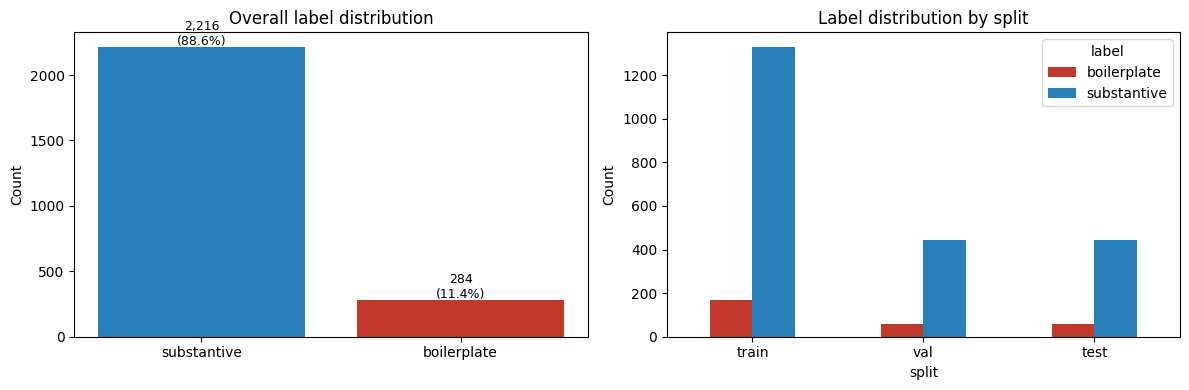

**Class balance**: 284 boilerplate (11.4%) vs 2,216 substantive (88.6%). Imbalance ratio ≈ 1 : 7.8.

In [6]:

# Class balance visualization
if gold_final is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    label_counts = gold_final["label"].value_counts()
    colors = {"boilerplate": "#c0392b", "substantive": "#2980b9"}
    bar_colors = [colors.get(l, "#888") for l in label_counts.index]
    bars = axes[0].bar(label_counts.index, label_counts.values, color=bar_colors)
    axes[0].set_title("Overall label distribution")
    axes[0].set_ylabel("Count")
    for bar, v in zip(bars, label_counts.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, v + 15,
                     f"{v:,}\n({v / len(gold_final):.1%})", ha="center", fontsize=9)

    split_label = gold_final.groupby(["split", "label"]).size().unstack(fill_value=0)
    split_label = split_label.reindex(["train", "val", "test"])
    split_label.plot(kind="bar", ax=axes[1],
                     color=[colors.get(c, "#888") for c in split_label.columns], rot=0)
    axes[1].set_title("Label distribution by split")
    axes[1].set_ylabel("Count")
    axes[1].legend(title="label")

    plt.tight_layout()
    plt.show()

    bp = label_counts.get("boilerplate", 0)
    sub = label_counts.get("substantive", 0)
    display(Markdown(
        f"**Class balance**: {bp:,} boilerplate ({bp/len(gold_final):.1%}) "
        f"vs {sub:,} substantive ({sub/len(gold_final):.1%}). "
        f"Imbalance ratio ≈ 1 : {sub/max(bp,1):.1f}."
    ))


## 3. Feature cache

`features` writes regex/surface features to Parquet and sentence embeddings to NumPy cache.

,sentence_id,split,label,sentence_text,has_operator,has_greeting,has_thank_you,has_forward_looking,has_non_gaap,has_sec,has_webcast_replay,has_investor_relations,has_next_question,has_turn_transition,has_speaker_intro,has_slide_reference,has_dollar_amount,has_percent,has_period_comparison,has_guidance_outlook,has_margin,has_revenue_earnings,has_cash_flow_capital,has_strategy,has_demand_pricing,has_customer_product,has_segment_region,has_operations_supply,has_ai_cloud_data_center,has_management_view,has_action_verbs,has_causal_explanation,has_business_question,has_qanda,char_len,token_len,digit_count,upper_ratio,punct_count,question_mark
0,26854,val,substantive,"You shouldn't interpolate that, that means every quarter, it will be this strong.",0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,81,13,0,0.012346,2,0
1,9315,train,substantive,"And I do believe we have some exciting announcements in the coming years, on how we could play a larger role on this whole idea of the t...",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,179,33,0,0.011173,1,0
2,23750,train,substantive,And then we'll continue to enhance our priority economy product offerings.,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,74,11,0,0.013514,0,0
3,9356,test,substantive,We've launched almost all our active strategies that are new strategies in the last few years in ETF format.,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,108,19,0,0.037037,0,0
4,32048,train,boilerplate,I'm hoping that's what you meant for 18A.,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41,8,2,0.048780,0,0


Rows: **2,500** | Columns: **40**

,share_triggered
has_period_comparison,0.1444
has_customer_product,0.1372
has_percent,0.1052
has_dollar_amount,0.0880
has_business_question,0.0836
has_revenue_earnings,0.0772
has_guidance_outlook,0.0744
has_causal_explanation,0.0656
has_ai_cloud_data_center,0.0592
has_demand_pricing,0.0448


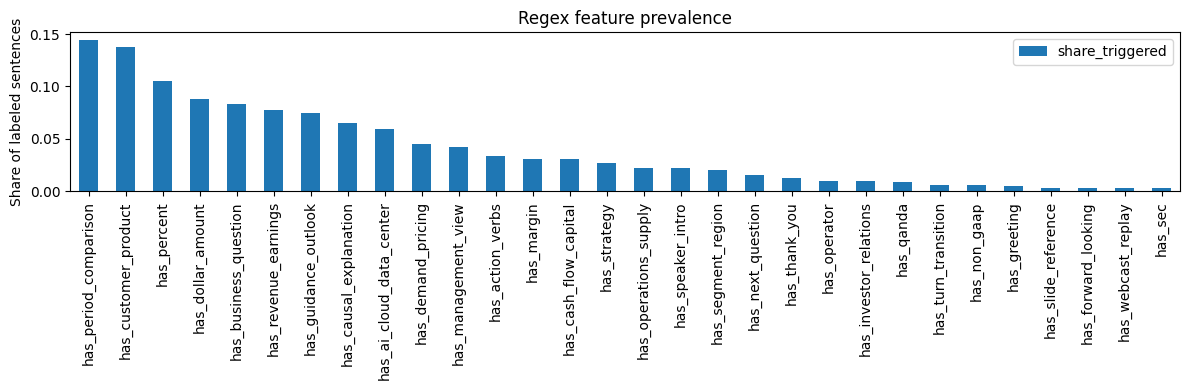

,char_len,token_len,digit_count,upper_ratio,punct_count,question_mark
label,,,,,,
boilerplate,82.42,13.99,0.55,0.06,1.17,0.03
substantive,124.97,21.50,1.18,0.02,1.53,0.07


Embeddings cache: `data\cache\embeddings_all.npy` with shape **(2500, 1024)** and dtype **float32**.

In [7]:
features_path = PATHS["interim"] / "features_regex.parquet"
embeddings_path = PATHS["cache"] / "embeddings_all.npy"

features = read_parquet_if_exists(features_path)

if features is None:
    show_missing(features_path, "features")
else:
    preview_df(features)
    regex_cols = [c for c in features.columns if c.startswith("has_")]
    surface_cols = ["char_len", "token_len", "digit_count", "upper_ratio", "punct_count", "question_mark"]
    if regex_cols:
        regex_rate = features[regex_cols].mean().sort_values(ascending=False).rename("share_triggered").to_frame()
        display(regex_rate)
        regex_rate.plot(kind="bar", figsize=(12, 4), title="Regex feature prevalence")
        plt.ylabel("Share of labeled sentences")
        plt.tight_layout()
        plt.show()
    existing_surface = [c for c in surface_cols if c in features.columns]
    if existing_surface:
        display(features.groupby("label")[existing_surface].mean().round(2))

if embeddings_path.exists():
    emb = np.load(embeddings_path, mmap_mode="r")
    display(Markdown(f"Embeddings cache: `{rel(embeddings_path)}` with shape **{emb.shape}** and dtype **{emb.dtype}**."))
else:
    show_missing(embeddings_path, "features")

## 4. Trained model artifacts

In [8]:
manifest_path = PATHS["artifacts"] / "models" / "manifest.json"
manifest = read_json_if_exists(manifest_path)

if manifest is None:
    show_missing(manifest_path, "train_all")
else:
    manifest_df = pd.DataFrame(manifest)
    manifest_df["exists"] = manifest_df["path"].apply(lambda p: (PATHS["artifacts"] / p).exists())
    display(manifest_df)

model_files = sorted((PATHS["artifacts"] / "models").glob("*")) if (PATHS["artifacts"] / "models").exists() else []
if model_files:
    display(pd.DataFrame({"model_artifact": [rel(p) for p in model_files], "is_dir": [p.is_dir() for p in model_files]}))

,family,path,train_seconds,exists
0,rules_regex,models/rules_regex.pkl,NaN,True
1,linear_embeddings,models/linear_embeddings.pkl,0.096976,True
2,tree_enriched,models/tree_enriched.pkl,7.303680,True
3,fasttext,models/fasttext.bin,5.971453,True
4,finbert,models/finbert,2180.428295,True
5,setfit,models/setfit,1649.840926,True


,model_artifact,is_dir
0,artifacts\models\ensemble.json,False
1,artifacts\models\fasttext.bin,False
2,artifacts\models\fasttext_train.txt,False
3,artifacts\models\finbert,True
4,artifacts\models\linear_embeddings.pkl,False
5,artifacts\models\manifest.json,False
6,artifacts\models\rules_regex.pkl,False
7,artifacts\models\setfit,True
8,artifacts\models\tree_enriched.pkl,False


## 5. Threshold tuning

`tune_thresholds` searches boilerplate-probability thresholds while enforcing the configured substantive-recall floor.

,threshold,threshold_mean,threshold_std,fold_thresholds,pooled_oof_macro_f1,pooled_oof_substantive_recall,pooled_oof_meets_floor,recall_floor,method,weight_metric,include_transformers,topk_members,weights
rules_regex,0.22,0.344,0.1602,"[0.22, 0.21000000000000002, 0.21000000000000002, 0.55, 0.53]",0.798503,0.987028,True,0.96,NaN,NaN,NaN,NaN,NaN
linear_embeddings,0.67,0.692,0.098468,"[0.59, 0.61, 0.65, 0.85, 0.76]",0.908784,0.980259,True,0.96,NaN,NaN,NaN,NaN,NaN
tree_enriched,0.16,0.122,0.144969,"[0.01, 0.04, 0.39, 0.16, 0.01]",0.913302,0.989284,True,0.96,NaN,NaN,NaN,NaN,NaN
fasttext,0.2,0.288,0.111964,"[0.2, 0.2, 0.22, 0.49, 0.33]",0.894882,0.981387,True,0.96,NaN,NaN,NaN,NaN,NaN
ensemble,0.33,NaN,NaN,NaN,0.936274,0.986464,True,0.96,weighted_probability,pooled_oof_macro_f1,True,"[setfit, finbert, tree_enriched, linear_embeddings, fasttext]","{'setfit': 0.9357659678921602, 'finbert': 0.9273376515528982, 'tree_enriched': 0.913301859281036, 'linear_embeddings': 0.908784148934242..."
finbert,0.73,0.38,0.235117,"[0.29000000000000004, 0.15000000000000002, 0.73, 0.5800000000000001, 0.15000000000000002]",0.927338,0.990412,True,0.96,NaN,NaN,NaN,NaN,NaN
setfit,0.6,0.312,0.230078,"[0.03, 0.25, 0.56, 0.12, 0.6]",0.935766,0.993796,True,0.96,NaN,NaN,NaN,NaN,NaN


,threshold,substantive_recall,macro_f1,meets_floor,family,fold,fold_name
0,0.000037,0.000000,0.101124,False,linear_embeddings,0,NaN
1,0.010000,0.538028,0.526982,False,linear_embeddings,0,NaN
2,0.020000,0.687324,0.631226,False,linear_embeddings,0,NaN
3,0.030000,0.766197,0.683894,False,linear_embeddings,0,NaN
4,0.040000,0.794366,0.708395,False,linear_embeddings,0,NaN


Rows: **3,633** | Columns: **7**

,best_macro_f1,max_substantive_recall,feasible_points
family,,,
tree_enriched,0.962441,1.0,598
finbert,0.957415,1.0,582
setfit,0.954861,1.0,586
linear_embeddings,0.945248,1.0,312
ensemble,0.936274,1.0,87
fasttext,0.924449,1.0,555
rules_regex,0.854609,1.0,404


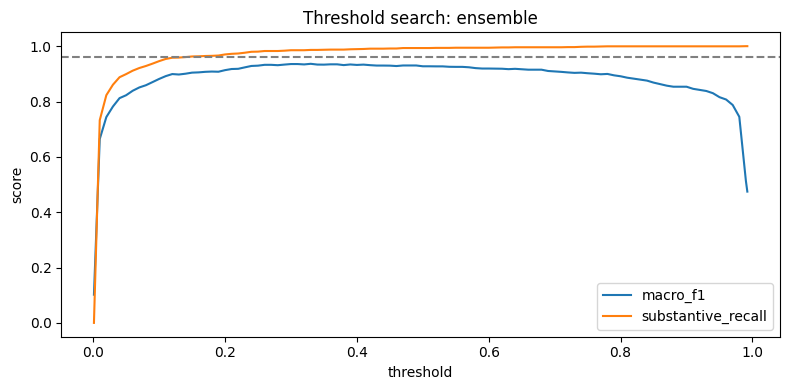

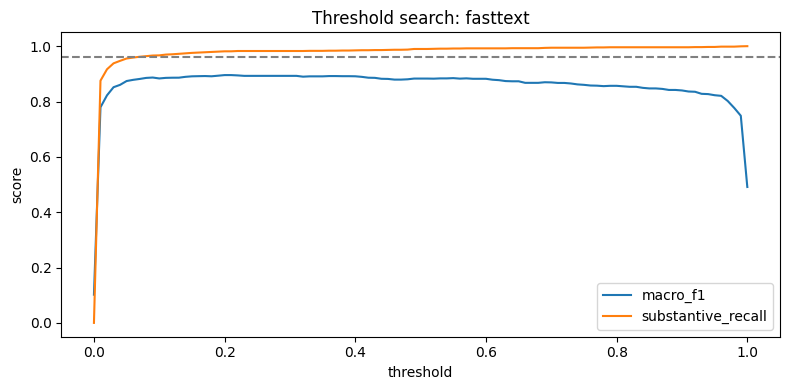

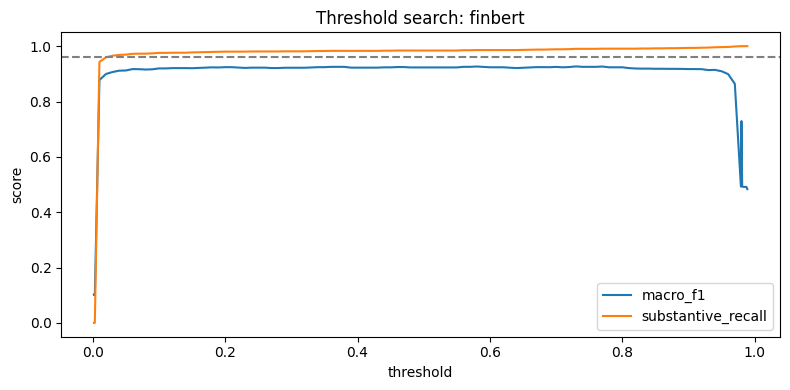

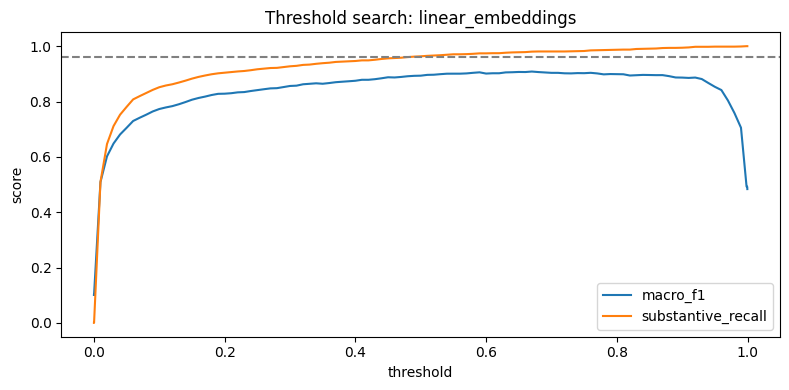

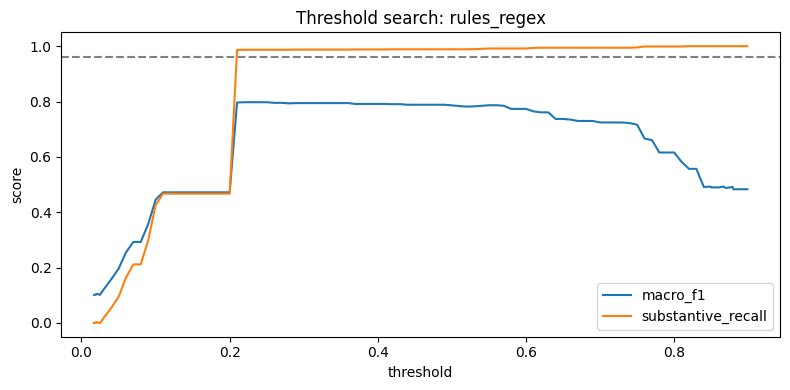

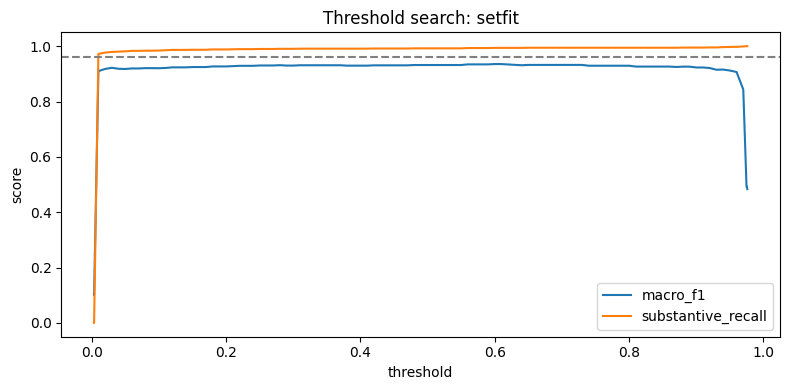

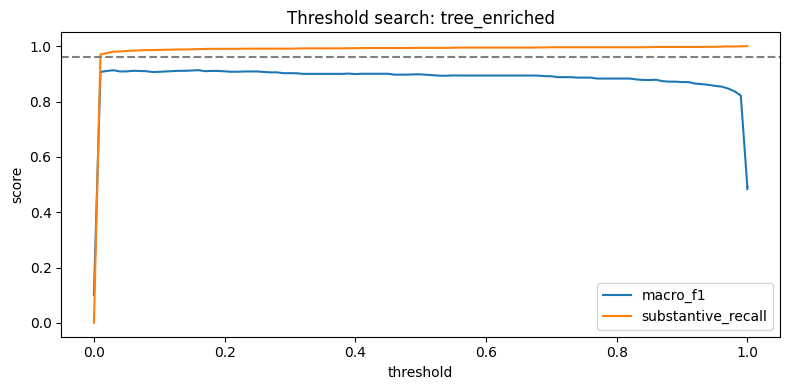

In [9]:
best_thresholds_path = OUT["thresholds"] / "best_thresholds.json"
threshold_search_path = OUT["thresholds"] / "threshold_search.parquet"

best_thresholds = read_json_if_exists(best_thresholds_path)
threshold_search = read_parquet_if_exists(threshold_search_path)

if best_thresholds is None:
    show_missing(best_thresholds_path, "tune_thresholds")
else:
    display(pd.DataFrame(best_thresholds).T)

if threshold_search is None:
    show_missing(threshold_search_path, "tune_thresholds")
else:
    preview_df(threshold_search)
    summary = threshold_search.groupby("family").agg(
        best_macro_f1=("macro_f1", "max"),
        max_substantive_recall=("substantive_recall", "max"),
        feasible_points=("meets_floor", "sum"),
    ).sort_values("best_macro_f1", ascending=False)
    display(summary)
    for family, fam_df in threshold_search.groupby("family"):
        curve = fam_df.groupby("threshold")[["macro_f1", "substantive_recall"]].mean()
        ax = curve.plot(figsize=(8, 4), title=f"Threshold search: {family}")
        ax.axhline(cfg["project"]["recall_floor_substantive"], linestyle="--", color="gray", label="recall floor")
        ax.set_ylabel("score")
        plt.tight_layout()
        plt.show()

## 6. Evaluation leaderboard and confusion matrices

,accuracy,macro_f1,boilerplate_precision,boilerplate_recall,boilerplate_f1,substantive_precision,substantive_recall,substantive_f1,family,threshold,inference_sent_per_sec,recall_floor_pass
0,0.980,0.950497,0.912281,0.912281,0.912281,0.988713,0.988713,0.988713,ensemble,0.35,NaN,True
1,0.978,0.944264,0.925926,0.877193,0.900901,0.984305,0.990971,0.987627,setfit,0.60,151.650594,True
2,0.978,0.942439,0.960000,0.842105,0.897196,0.980000,0.995485,0.987682,finbert,0.73,12.063218,True
3,0.966,0.918923,0.822581,0.894737,0.857143,0.986301,0.975169,0.980704,linear_embeddings,0.67,129332.644076,True
4,0.966,0.915196,0.857143,0.842105,0.849558,0.979730,0.981941,0.980834,tree_enriched,0.16,328.775389,True
5,0.958,0.896831,0.810345,0.824561,0.817391,0.977376,0.975169,0.976271,fasttext,0.20,418.202900,True
6,0.912,0.746497,0.666667,0.456140,0.541667,0.932755,0.970655,0.951327,rules_regex,0.22,8837.341654,True


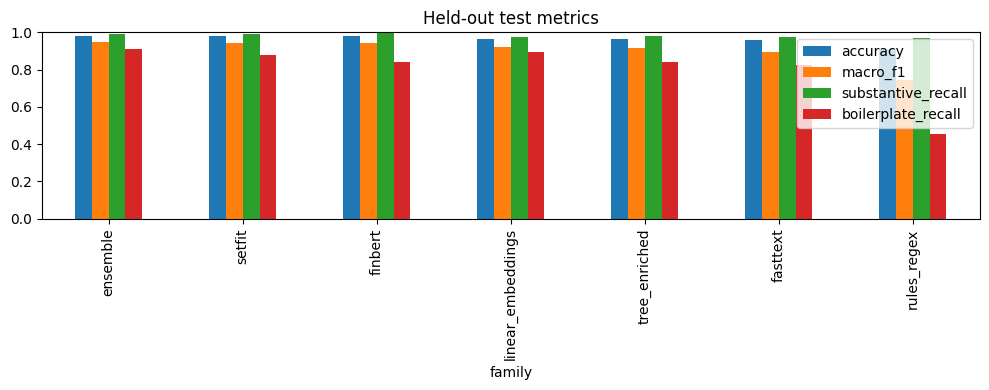

### Best model selection

,value
accuracy,0.98
macro_f1,0.950497
boilerplate_precision,0.912281
boilerplate_recall,0.912281
boilerplate_f1,0.912281
substantive_precision,0.988713
substantive_recall,0.988713
substantive_f1,0.988713
family,ensemble
threshold,0.35


### Confusion matrices

`artifacts\figures\cm_ensemble.png`

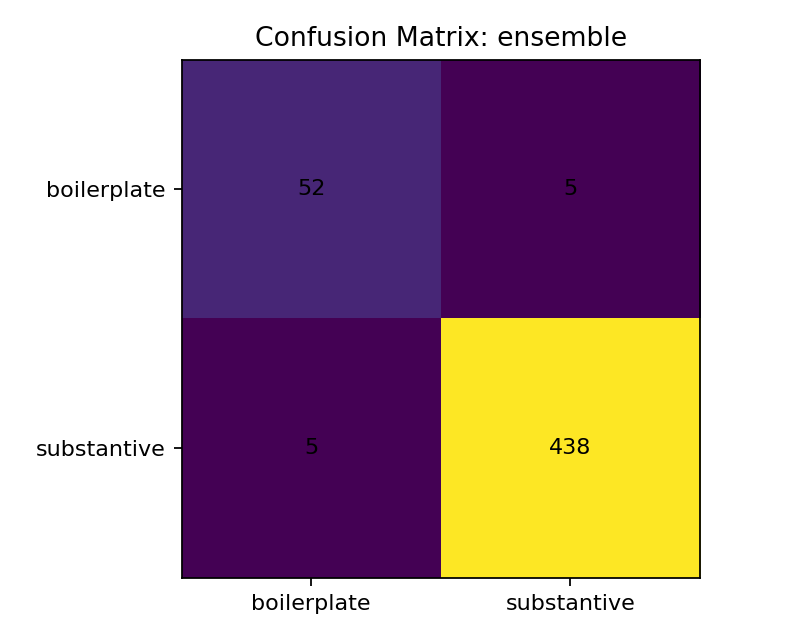

`artifacts\figures\cm_fasttext.png`

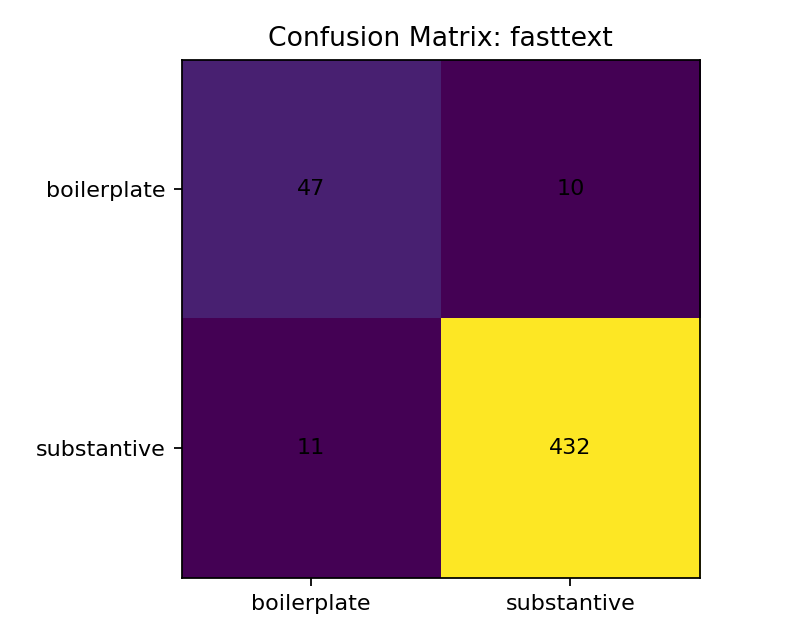

`artifacts\figures\cm_finbert.png`

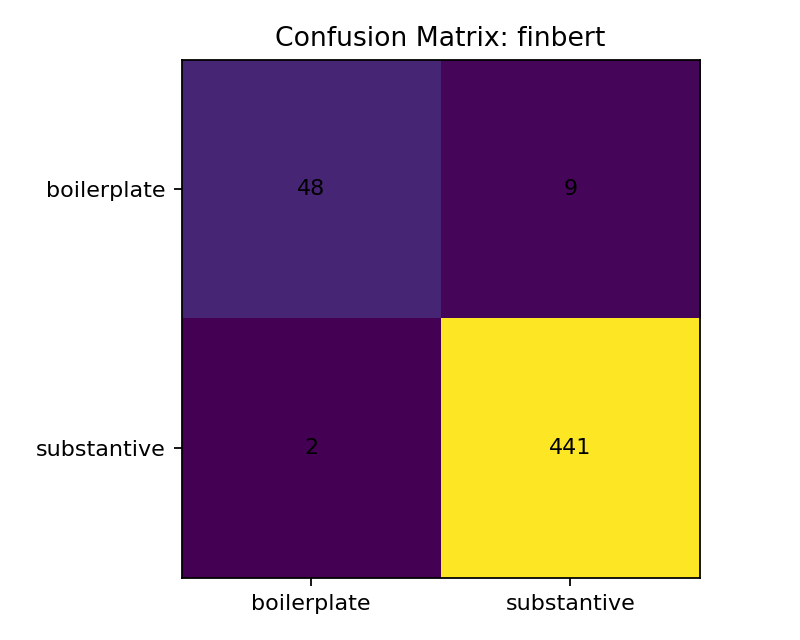

`artifacts\figures\cm_linear_embeddings.png`

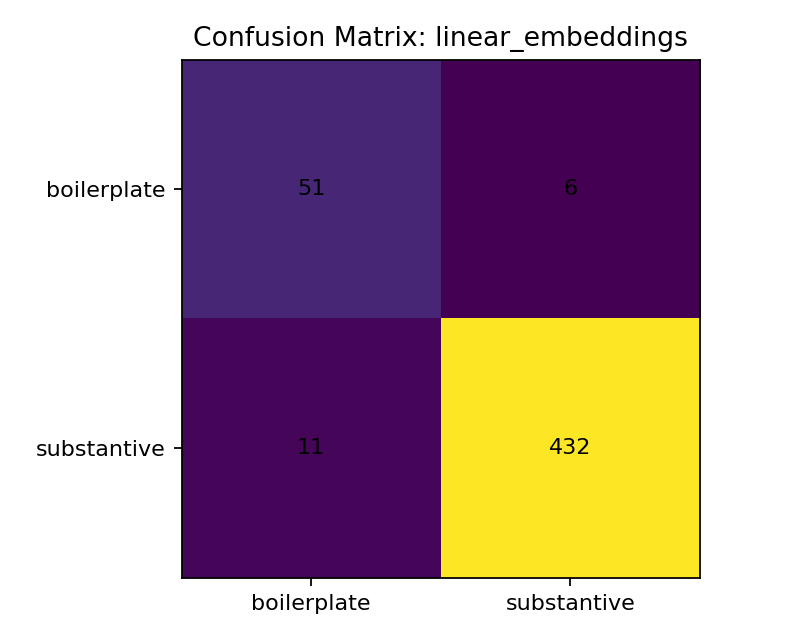

`artifacts\figures\cm_rules_regex.png`

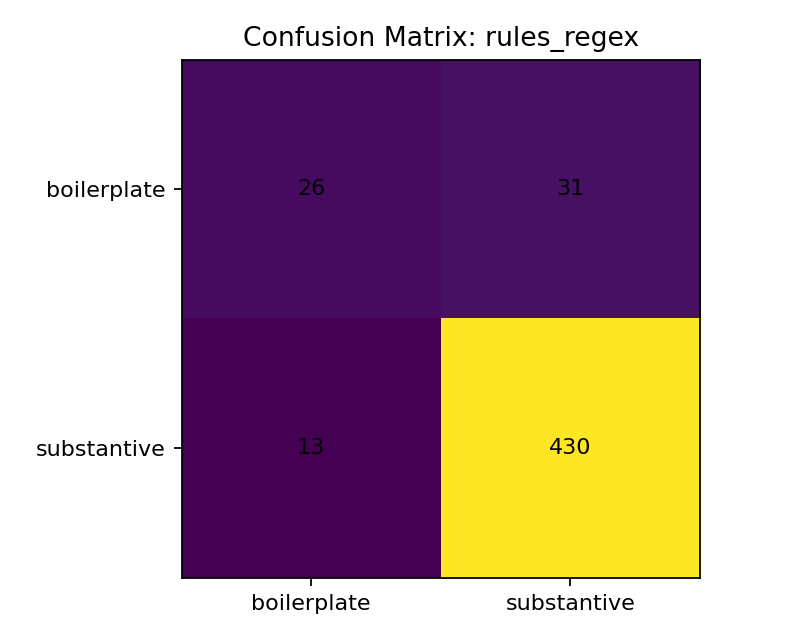

`artifacts\figures\cm_setfit.png`

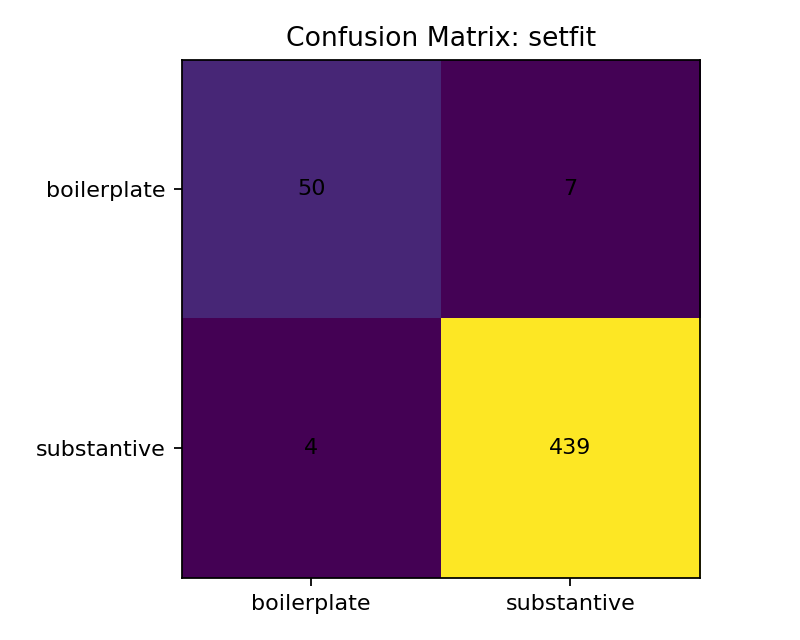

`artifacts\figures\cm_tree_enriched.png`

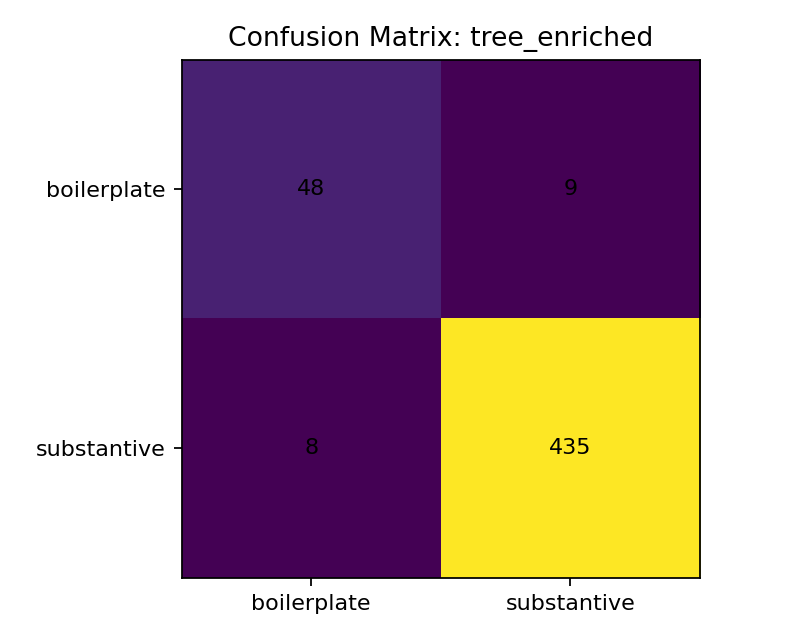

In [10]:
leaderboard_path = OUT["evaluation"] / "leaderboard.parquet"
leaderboard_csv_path = OUT["evaluation"] / "leaderboard.csv"
best_model_path = OUT["evaluation"] / "best_model_selection.json"

leaderboard = read_parquet_if_exists(leaderboard_path)
if leaderboard is None and leaderboard_csv_path.exists():
    leaderboard = pd.read_csv(leaderboard_csv_path)

if leaderboard is None:
    show_missing(leaderboard_path, "evaluate")
else:
    display(leaderboard)
    metric_cols = ["accuracy", "macro_f1", "substantive_recall", "boilerplate_recall"]
    existing_metrics = [c for c in metric_cols if c in leaderboard.columns]
    if existing_metrics:
        leaderboard.set_index("family")[existing_metrics].plot(kind="bar", figsize=(10, 4), ylim=(0, 1), title="Held-out test metrics")
        plt.tight_layout()
        plt.show()

best_model = read_json_if_exists(best_model_path)
if best_model is not None:
    display(Markdown("### Best model selection"))
    display(pd.Series(best_model).to_frame("value"))

figure_dir = PATHS["artifacts"] / "figures"
figures = sorted(figure_dir.glob("cm_*.png")) if figure_dir.exists() else []
if figures:
    display(Markdown("### Confusion matrices"))
    for fig in figures:
        display(Markdown(f"`{rel(fig)}`"))
        display(Image(filename=str(fig)))
else:
    show_missing(figure_dir / "cm_<family>.png", "evaluate")

## 7. Error analysis exports

In [11]:
error_path = OUT["error_analysis"] / "error_analysis.parquet"
error_csv_path = OUT["error_analysis"] / "error_analysis.csv"
error_df = read_parquet_if_exists(error_path)
if error_df is None and error_csv_path.exists():
    error_df = pd.read_csv(error_csv_path)

if error_df is None:
    show_missing(error_path, "evaluate")
else:
    preview_df(error_df)
    if "is_error" in error_df.columns:
        display(error_df["is_error"].value_counts().rename("count").to_frame())
        display(Markdown("### Example errors"))
        preview_df(error_df[error_df["is_error"]].sort_values("boilerplate_proba", ascending=False), n=10)

family_error_files = sorted(OUT["error_analysis"].glob("error_analysis_*.csv")) if OUT["error_analysis"].exists() else []
if family_error_files:
    display(Markdown("### Per-family error files"))
    display(pd.DataFrame({"file": [rel(p) for p in family_error_files]}))
    for path in family_error_files[:3]:
        fam = path.stem.replace("error_analysis_", "")
        fam_df = pd.read_csv(path)
        display(Markdown(f"#### {fam}"))
        display(fam_df.head())
        if "is_error" in fam_df.columns:
            display(fam_df["is_error"].value_counts().rename("count").to_frame())

,sentence_id,sentence_text,label,pred_label,boilerplate_proba,is_error
0,9356,We've launched almost all our active strategies that are new strategies in the last few years in ETF format.,substantive,substantive,0.001666,False
1,8299,"Throughout BlackRock's history, we've been relentless and anticipating the future needs of our clients and taking strategic actions to e...",substantive,substantive,0.001616,False
2,45509,The next industrial revolution has begun.,substantive,substantive,0.002961,False
3,21241,"Well, thank you, Bascome, for raising that question.",boilerplate,boilerplate,0.981630,False
4,9234,We manage the largest crypto asset ETP with over $100 billion in AUM.,substantive,substantive,0.001990,False


Rows: **500** | Columns: **6**

,count
is_error,
False,490
True,10


### Example errors

,sentence_id,sentence_text,label,pred_label,boilerplate_proba,is_error
252,41339,Question Analysts - Senior MD & Senior Research Analyst So I want to ask you on the stablecoin issue.,substantive,boilerplate,0.632477,True
458,25416,"Well, first, I'll comment on the macro, Steven.",substantive,boilerplate,0.588180,True
290,18620,And I'd be careful how I say this because I don't want to send a message internally to confuse people.,substantive,boilerplate,0.570202,True
118,579,And wanted to double-click on Client in particular.,substantive,boilerplate,0.558686,True
251,32059,"So I'll say Q4 to Q1, all explainable in those context.",substantive,boilerplate,0.449799,True
444,3804,"Let the numbers speak for themselves, please, and leave it that way.",boilerplate,substantive,0.273337,True
246,7326,I want to just thank everybody and have a calm second quarter.,boilerplate,substantive,0.093528,True
282,20651,"Since 2001, she has led Government and Regulatory Affairs.",boilerplate,substantive,0.026709,True
378,19423,But I had a really nice visit with him with a handful of us that are touring it.,boilerplate,substantive,0.019619,True
36,40075,"But just for the sake of helping you tidy up models, I wanted to make that point.",boilerplate,substantive,0.013778,True


...

,sentence_id,sentence_text,label,pred_label,boilerplate_proba,is_error
0,9356,We've launched almost all our active strategies that are new strategies in the last few years in ETF format.,substantive,substantive,0.000305,False
1,8299,"Throughout BlackRock's history, we've been relentless and anticipating the future needs of our clients and taking strategic actions to e...",substantive,substantive,0.009314,False
2,45509,The next industrial revolution has begun.,substantive,substantive,0.020517,False
3,21241,"Well, thank you, Bascome, for raising that question.",boilerplate,boilerplate,0.993971,False
4,9234,We manage the largest crypto asset ETP with over $100 billion in AUM.,substantive,substantive,0.000023,False


,count
is_error,
False,479
True,21


#### finbert

,sentence_id,sentence_text,label,pred_label,boilerplate_proba,is_error
0,9356,We've launched almost all our active strategies that are new strategies in the last few years in ETF format.,substantive,substantive,0.001685,False
1,8299,"Throughout BlackRock's history, we've been relentless and anticipating the future needs of our clients and taking strategic actions to e...",substantive,substantive,0.001535,False
2,45509,The next industrial revolution has begun.,substantive,substantive,0.005104,False
3,21241,"Well, thank you, Bascome, for raising that question.",boilerplate,boilerplate,0.979225,False
4,9234,We manage the largest crypto asset ETP with over $100 billion in AUM.,substantive,substantive,0.001811,False


,count
is_error,
False,489
True,11


## 8. Write-up support files

In [12]:
notes_path = OUT["evaluation"] / "family_writeup_notes.json"
refs_path = OUT["evaluation"] / "references_export.json"
package_path = PATHS["artifacts"] / "best_model" / "metadata.json"

for title, path, stage in [
    ("Family write-up notes", notes_path, "evaluate"),
    ("References export", refs_path, "evaluate"),
    ("Packaged best model metadata", package_path, "package_best"),
]:
    display(Markdown(f"### {title}"))
    obj = read_json_if_exists(path)
    if obj is None:
        show_missing(path, stage)
    else:
        display(obj if isinstance(obj, list) else pd.Series(obj).to_frame("value") if not any(isinstance(v, dict) for v in (obj.values() if isinstance(obj, dict) else [])) else obj)

### Family write-up notes

{'rules_regex': {'n_test': 500,
  'n_errors': 44,
  'likely_strength': 'High boilerplate precision on stereotyped patterns',
  'likely_failure_mode': 'Mixed or ambiguous sentences',
  'example_error_sentence': 'Well, thank you, Bascome, for raising that question.'},
 'linear_embeddings': {'n_test': 500,
  'n_errors': 17,
  'likely_strength': 'Captures broader semantic context',
  'likely_failure_mode': 'Mixed or ambiguous sentences',
  'example_error_sentence': 'Analysts - Research Analyst Some regional banks have pointed to...'},
 'tree_enriched': {'n_test': 500,
  'n_errors': 17,
  'likely_strength': 'Captures broader semantic context',
  'likely_failure_mode': 'Mixed or ambiguous sentences',
  'example_error_sentence': 'He has served as CIO for the last 24 years leading FedEx in modernizing our IT infrastructure.'},
 'fasttext': {'n_test': 500,
  'n_errors': 21,
  'likely_strength': 'Captures broader semantic context',
  'likely_failure_mode': 'Mixed or ambiguous sentences',
  'exam

### References export

{'libraries': ['scikit-learn',
  'sentence-transformers',
  'transformers',
  'setfit',
  'streamlit',
  'nltk',
  'openai',
  'anthropic',
  'requests',
  'pyarrow'],
 'pretrained_models': {'sentence_embedding_model': 'mxbai-embed-large',
  'finbert': 'ProsusAI/finbert',
  'setfit': 'sentence-transformers/all-MiniLM-L6-v2',
  'ollama_judge': ['qwen3:4b']},
 'apis': ['openai', 'anthropic', 'ollama']}

### Packaged best model metadata

{'family': 'ensemble',
 'threshold': 0.35000000000000003,
 'ensemble': {'method': 'weighted_probability',
  'weight_metric': 'pooled_oof_macro_f1',
  'include_transformers': True,
  'topk_members': ['setfit',
   'finbert',
   'tree_enriched',
   'linear_embeddings',
   'fasttext'],
  'weights': {'setfit': 0.9357659678921602,
   'finbert': 0.9273376515528982,
   'tree_enriched': 0.913301859281036,
   'linear_embeddings': 0.9087841489342428,
   'fasttext': 0.8948823066411307},
  'threshold': 0.33}}

## Missing-artifacts checklist

In [13]:
expected = [
    (PATHS["interim"] / cfg["sentence_pool"]["output_file"], "extract"),
    (PATHS["interim"] / "gold_candidates.parquet", "sample_gold"),
    (PATHS["interim"] / "judge_outputs.parquet", "label_gold"),
    (PATHS["interim"] / "audit_sample.csv", "audit_sample"),
    (PATHS["interim"] / "gold_final.parquet", "finalize_gold"),
    (PATHS["interim"] / "features_regex.parquet", "features"),
    (PATHS["cache"] / "embeddings_all.npy", "features"),
    (PATHS["artifacts"] / "models" / "manifest.json", "train_all"),
    (OUT["thresholds"]     / "best_thresholds.json",      "tune_thresholds"),
    (OUT["thresholds"]     / "threshold_search.parquet",  "tune_thresholds"),
    (OUT["evaluation"]     / "leaderboard.parquet",       "evaluate"),
    (OUT["error_analysis"] / "error_analysis.parquet",    "evaluate"),
    (OUT["evaluation"]     / "best_model_selection.json", "evaluate"),
    (PATHS["artifacts"] / "best_model" / "metadata.json", "package_best"),
]

missing = [{"missing_file": rel(path), "stage_to_run": stage, "command": f"python main.py --stage {stage}"} for path, stage in expected if not path.exists()]
if missing:
    display(pd.DataFrame(missing))
else:
    display(Markdown("All expected core artifacts are present."))

All expected core artifacts are present.